# Toroidal Fuchs shell — cylindrical reduction (Task 2A.14)

**Scope (this notebook).** A *tractable* cylindrical reduction of the toroidal-Fuchs static junction problem: in the thin-torus limit $a / R_\text{maj} \ll 1$ (minor radius small relative to major radius), a local patch of the torus tube is well approximated by an infinite cylinder of radius $a$. The exterior of an infinite static cylinder admits a closed-form vacuum solution (the **Levi-Civita** metric), so the Israel-junction calculation closes symbolically — paralleling [`matter_shell.ipynb`](matter_shell.ipynb)'s spherical–Schwarzschild matching but with a different topology.

The deliverable is a thickness bound $\Delta_{\min}/R = \kappa_\text{cyl}\,\beta/C$ in the same dimensionless form as the spherical bound $\Delta_{\min}/R = \kappa_\text{sph}\,\beta/C$ with $\kappa_\text{sph} = 3/4$ (see [`thickness_bound.ipynb`](thickness_bound.ipynb) Cell 3 / Task 2A.9a).

**Out of scope.** The full fat-torus matching to a Weyl / Bach–Weyl axisymmetric vacuum exterior is harder: there is no closed-form regular asymptotically-flat vacuum solution sourced by a fat torus. Doing it properly requires numerical relativity (or at least a numerical Weyl-potential solve). That is recorded as scope (b) in [`TOROIDAL_FUCHS_NOTES.md`](TOROIDAL_FUCHS_NOTES.md) §3 and as an optional follow-up in ROADMAP 2A.14.

**Why bother with the cylindrical reduction at all.** The motivation is the speculation in [`speculation/RING_NETWORK_CONCEPT.md`](speculation/RING_NETWORK_CONCEPT.md) §4 that a *toroidal* Fuchs shell with azimuthal shift $\beta^\varphi$ might evade the spherical no-go. In the local cylindrical limit the azimuthal shift becomes an axial shift $\beta^z$ along the cylinder, and the question becomes: does the cylindrical thickness bound have a more permissive $\kappa_\text{cyl}$, or does it close at least as tightly as the spherical case?

**Pre-computational expectation.** The shift along the cylinder's symmetry axis is $\varphi$-independent, so there is *no dipole modulation* around the cylinder (unlike the spherical case where the linear shift $\beta^x$ breaks $SO(3) \to SO(2)$ and produces an $l = 1$ angular structure). The "worst angle" is therefore everywhere — every point on the shell sees the same shift gradient. This eliminates the pole-dominance factor that gave $\kappa_\text{sph} = 3/4$ from a $\cos\theta$ projection at $\theta = \pi$. The naive prediction is a *different* $O(1)$ coefficient — let's see what it is.


## 1. Symbolic setup

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Rational, sqrt, simplify, log, series, Symbol, Matrix, sin, cos, pi, diff, oo, Piecewise

print(f"SymPy {sp.__version__}, NumPy {np.__version__}")

# Geometric symbols (G = c = 1 throughout).
rho, z, phi_c = symbols('rho z phi', real=True)
R, Delta = symbols('R Delta', positive=True)         # cylinder radius (= torus minor radius a) and shell thickness
M, L = symbols('M L', positive=True)                 # equivalent total mass and cylinder axial length
mu_lin = M / L                                       # linear mass density
beta = symbols('beta', positive=True)                # shift amplitude (interior shift)
sig = symbols('sigma', positive=True)                # Levi-Civita parameter (linear mass-density-like)

print("Linear mass density mu = M/L =", mu_lin)
print("Spherical reference kappa_sph = 3/4 from thickness_bound.ipynb Cell 3")


SymPy 1.14.0, NumPy 2.4.2
Linear mass density mu = M/L = M/L
Spherical reference kappa_sph = 3/4 from thickness_bound.ipynb Cell 3


## 2. Static cylindrical shell — flat interior matched to Levi-Civita exterior

The Levi-Civita vacuum is the unique static cylindrically-symmetric vacuum solution. In the (Bonnor-canonical) form linearized about Minkowski to first order in $\sigma$:

$$ds^2_+ \;=\; -\bigl(1 + 4\sigma \ln(\rho / R)\bigr)\, dt^2 \;+\; \bigl(1 - 4\sigma \ln(\rho / R)\bigr)\bigl(d\rho^2 + dz^2\bigr) \;+\; \rho^2 \bigl(1 - 4\sigma \ln(\rho / R)\bigr)\, d\varphi^2$$

(I have set the gauge $\rho_0 = R$ so $g_{tt}|_{\rho = R} = -1$ exactly — this absorbs the $\ln R$ that would otherwise contaminate the asymptotic mass identification, which is well-known to be gauge-dependent for Levi-Civita.) The parameter $\sigma$ is the linearized analog of $G\mu/c^2$ for an infinite line mass; we'll connect it to $M/L$ below.

The interior is flat Minkowski: $ds^2_- = -dt^2 + d\rho^2 + dz^2 + \rho^2 d\varphi^2$.

We do the Israel-junction calculation symbolically to first order in $\sigma$ (small linear-mass-density limit, equivalent to weak-field), and extract the static-shell surface stress-energy $S^a_{\;b}$.


In [2]:
# Linearized Levi-Civita exterior, gauge: g_tt = -1 at rho = R.
# Work to first order in sigma. We'll construct g_+_ab(rho) explicitly.

eps = sp.Symbol('eps', positive=True)  # bookkeeping for "small" sigma

g_plus_tt   = -(1 + 4*sig * sp.log(rho / R))
g_plus_rho  =  1 - 4*sig * sp.log(rho / R)
g_plus_zz   =  1 - 4*sig * sp.log(rho / R)
g_plus_phi  = rho**2 * (1 - 4*sig * sp.log(rho / R))

print("Exterior metric components at general rho:")
for name, expr in [("g_tt", g_plus_tt), ("g_rho", g_plus_rho),
                   ("g_zz", g_plus_zz), ("g_phi", g_plus_phi)]:
    print(f"  {name:7s} = {expr}")

# Outward unit normal n^mu = (1/sqrt(g_rho)) d/drho.
# Extrinsic curvature K^+_ab = (1/(2 sqrt(g_rho))) d_rho g_ab evaluated at rho = R.
# Components on the shell: (t, z, phi).

def K_plus(g_ab):
    return (sp.diff(g_ab, rho) / (2 * sp.sqrt(g_plus_rho))).subs(rho, R)

K_plus_tt  = sp.simplify(sp.series(K_plus(g_plus_tt),  sig, 0, 2).removeO())
K_plus_zz  = sp.simplify(sp.series(K_plus(g_plus_zz),  sig, 0, 2).removeO())
K_plus_phi = sp.simplify(sp.series(K_plus(g_plus_phi), sig, 0, 2).removeO())

print("\nExterior K_ab on shell (first order in sigma):")
print("  K^+_tt   =", K_plus_tt)
print("  K^+_zz   =", K_plus_zz)
print("  K^+_phi  =", K_plus_phi)


Exterior metric components at general rho:
  g_tt    = -4*sigma*log(rho/R) - 1
  g_rho   = -4*sigma*log(rho/R) + 1
  g_zz    = -4*sigma*log(rho/R) + 1
  g_phi   = rho**2*(-4*sigma*log(rho/R) + 1)

Exterior K_ab on shell (first order in sigma):
  K^+_tt   = -2*sigma/R
  K^+_zz   = -2*sigma/R
  K^+_phi  = R*(1 - 2*sigma)


In [3]:
# Interior (flat Minkowski) extrinsic curvature on the cylinder rho = R.
# Same metric form with sigma = 0, so:
g_minus_phi = rho**2

K_minus_tt  = sp.S(0)
K_minus_zz  = sp.S(0)
K_minus_phi = sp.diff(g_minus_phi, rho).subs(rho, R) / 2   # = R

print("Interior K_ab on shell (Minkowski):")
print("  K^-_tt   =", K_minus_tt)
print("  K^-_zz   =", K_minus_zz)
print("  K^-_phi  =", K_minus_phi)

# Induced metric on the shell (both sides agree at rho = R because of our gauge choice):
h_tt   = -1
h_zz   = +1
h_phi  = R**2

# Jumps [K_ab] = K^+_ab - K^-_ab
jK_tt  = sp.simplify(K_plus_tt  - K_minus_tt)
jK_zz  = sp.simplify(K_plus_zz  - K_minus_zz)
jK_phi = sp.simplify(K_plus_phi - K_minus_phi)
print("\nJumps [K_ab] = K^+ - K^-:")
print("  [K_tt]  =", jK_tt)
print("  [K_zz]  =", jK_zz)
print("  [K_phi] =", jK_phi)

# Trace of the jump: [K] = h^ab [K_ab] with h^ab = (-1, +1, 1/R^2).
trace_jK = sp.simplify(-jK_tt + jK_zz + jK_phi / R**2)
print("\nTrace of jump [K] =", trace_jK)


Interior K_ab on shell (Minkowski):
  K^-_tt   = 0
  K^-_zz   = 0
  K^-_phi  = R

Jumps [K_ab] = K^+ - K^-:
  [K_tt]  = -2*sigma/R
  [K_zz]  = -2*sigma/R
  [K_phi] = -2*R*sigma

Trace of jump [K] = -2*sigma/R


In [4]:
# Israel surface stress-energy: S_ab = -(1/(8 pi)) ([K_ab] - [K] h_ab)
# Then S^a_b = h^ac S_cb.

S_tt  = sp.simplify(-(jK_tt  - trace_jK * h_tt ) / (8 * sp.pi))
S_zz  = sp.simplify(-(jK_zz  - trace_jK * h_zz ) / (8 * sp.pi))
S_phi = sp.simplify(-(jK_phi - trace_jK * h_phi) / (8 * sp.pi))

# Mixed-index components (these are what DEC works on in the rest frame of the shell):
sigma_E = sp.simplify(-S_tt / h_tt)         # = -h^tt S_tt = -(-1) S_tt = S_tt times -1
                                            # (Recall S^t_t = h^tt S_tt; with h^tt = -1 => S^t_t = -S_tt;
                                            #  energy density is -S^t_t in mostly-plus signature.)
p_z     = sp.simplify(S_zz / h_zz)
p_phi   = sp.simplify(S_phi / h_phi)

print("Static-shell surface stress-energy (mixed components, first order in sigma):")
print("  surface energy density sigma_E =", sigma_E)
print("  axial pressure         p_z     =", p_z)
print("  hoop pressure          p_phi   =", p_phi)

# Sanity: a physical static shell needs sigma_E > 0 -> sigma > 0 (correct sign of mass).
# DEC for the static shell: sigma_E >= |p_z|, sigma_E >= |p_phi|.
print("\nDEC of static shell:")
print("  sigma_E - |p_z|   =", sp.simplify(sigma_E - sp.Abs(p_z)))
print("  sigma_E - |p_phi| =", sp.simplify(sigma_E - sp.Abs(p_phi)))


Static-shell surface stress-energy (mixed components, first order in sigma):
  surface energy density sigma_E = sigma/(2*pi*R)
  axial pressure         p_z     = 0
  hoop pressure          p_phi   = 0

DEC of static shell:
  sigma_E - |p_z|   = sigma/(2*pi*R)
  sigma_E - |p_phi| = sigma/(2*pi*R)


**Reading.** The static cylindrical shell has surface energy density $\sigma_E = \sigma / (2\pi R)$ (linear mass density per circumference, as expected — equivalent to $\mu / (2\pi R)$ if we identify $\sigma \leftrightarrow \mu/c^2$ in geometrized units), and *zero* tangential pressures $p_z = p_\varphi = 0$ at first order in $\sigma$. So a static dust cylindrical shell satisfies DEC trivially with margin $\sigma_E - 0 = \sigma_E > 0$.

This is the cylindrical analog of a static dust sphere ($\sigma_E > 0$, $p_\theta = p_\varphi = 0$ from Schwarzschild matching at weak field). No surprise here — the cylindrical case looks structurally similar to the spherical one at this stage.


## 3. Axial shift $\beta^z(\rho)$ — perturbative correction

Now turn on a shift $\beta^z(\rho)$ that goes from $\beta_0$ inside ($\rho < R$) to $0$ outside ($\rho > R + \Delta$), with a smooth transition over thickness $\Delta$. In the linearized regime, the shift contributes to the Eulerian (rest-frame) stress-energy via the standard ADM decomposition:

$$T^{tz} \;\sim\; \rho_\text{shell} \,\beta^z, \qquad T^{zz} \;\supset\; \frac{(\partial_\rho \beta^z)^2}{8\pi G}$$

(the $T^{zz}$ contribution from the shift gradient is the "Maxwell-like" stress of the gravitomagnetic-analogue field $\partial_\rho \beta^z$, with sign and coefficient analogous to the spherical case in [`thickness_bound.ipynb`](thickness_bound.ipynb) Cell 2).

Crucially, because the shift is along the cylinder's symmetry axis $z$, the perturbation is $\varphi$-independent. There is **no dipole modulation around $\varphi$** — every point on the cylindrical shell sees the same $\partial_\rho \beta^z$. This is the key structural difference from the spherical case, where the shift $\beta^x$ broke $SO(3) \to SO(2)$ and produced an $l = 1$ dipole in the surface stress with a $\cos\theta$ profile that picked up a worst-angle factor of $3/4$ at the anti-motion pole.


In [5]:
# Eulerian-frame DEC analysis, cylindrical case.
# Following thickness_bound.ipynb Cell 2's dimensional argument, but with the
# correct cylindrical mass-per-volume.
#
# Volumetric energy density inside the shell:
#   rho_vol_cyl = M / (cylinder volume) = M / (2 pi R Delta L)
# (Compare spherical: rho_vol_sph = M / (4 pi R^2 Delta).)
#
# Shift-induced anisotropic stress (worst component, no dipole averaging):
#   T_zz_aniso ~ (d beta / d rho)^2 / (8 pi G)
#              ~ beta^2 / (8 pi G Delta^2)
#   (Same dimensional form as spherical case; coefficient differs by factor
#    that we now derive.)
#
# DEC: rho_vol >= |T_zz_aniso|, i.e.
#   M / (2 pi R Delta L) >= beta^2 / (8 pi G Delta^2)
#   <=>  Delta >= beta^2 R L / (4 G M)                    [cylindrical, naive]
#
# To put it in the SAME dimensionless form as spherical, we use the
# *equivalent compactness* of a cylindrical shell: C_cyl = 2 G mu / (R c^2)
# with linear mass density mu = M/L. This is the natural cylindrical analog of
# the spherical compactness 2 G M / (R c^2).
#
# Substituting M = mu L:
#   Delta >= beta^2 R L / (4 G mu L) = beta^2 R / (4 G mu)
#         = (1/2) beta^2 / (2 G mu / R)
#         = (1/2) beta^2 / C_cyl

# That's the *naive* dimensional bound. The actual numerical coefficient comes
# from the worst-angle analysis. In the spherical case the dimensional bound
# (Cell 2 of thickness_bound) was Delta >= beta^2 R^2 / (G M), and the
# worst-angle pole-dominance refinement (Cell 3) gave Delta >= (3/8) beta R^2 /
# (G M), changing beta^2 -> beta and adding the 3/8 = (3/4) / 2 factor.
#
# For the cylindrical case, there is NO dipole modulation, so there is no
# pole-dominance enhancement OR suppression -- the worst-angle is everywhere.
# The "linear in beta, not beta^2" reduction (which in the spherical case came
# from the dipole structure: the surface density acquires a dipole correction
# sigma_1 ~ beta sigma_w, then DEC sigma_0 + sigma_1 >= |P_1| with
# P_1 ~ beta sigma_w gives a *linear* beta bound) STILL APPLIES because the
# axial-shift perturbation also induces a momentum flux T^{rho z} ~ beta sigma_w
# at the shell, and the corresponding correction to the rest-frame
# stress-energy is also linear in beta.

# Symbolic derivation of the cylindrical analog of thickness_bound Cell 3:
sigma_w_sym = sp.Symbol('sigma_w', positive=True)   # = 1/Delta
beta_sym = sp.Symbol('beta', positive=True)
M_sym = sp.Symbol('M', positive=True)
R_sym = sp.Symbol('R', positive=True)
L_sym = sp.Symbol('L', positive=True)

# Spherical case (recap from thickness_bound Cell 3):
#   sigma_0_sph    = M / (4 pi R^2)
#   sigma_1_sph    = -(beta sigma_w / (16 pi R)) at theta = pi
#   P_1_sph        = -(beta sigma_w / (32 pi R)) at theta = pi
#   DEC: sigma_0_sph + sigma_1_sph >= |P_1_sph|
sig0_sph = M_sym / (4*sp.pi * R_sym**2)
sig1_sph = -beta_sym * sigma_w_sym / (16*sp.pi * R_sym)
P1_sph   = -beta_sym * sigma_w_sym / (32*sp.pi * R_sym)
DEC_sph  = sp.simplify(sig0_sph + sig1_sph - sp.Abs(P1_sph))
print("Spherical DEC residual (= 0 at boundary):", DEC_sph)
Delta_min_sph = sp.solve(sig0_sph + sig1_sph - sp.Abs(P1_sph),
                         sigma_w_sym)[0]   # solve for sigma_w = 1/Delta_min
Delta_min_sph = 1 / Delta_min_sph
print("Spherical Delta_min =", sp.simplify(Delta_min_sph))


Spherical DEC residual (= 0 at boundary):

 (8*M - 3*R*beta*sigma_w)/(32*pi*R**2)
Spherical Delta_min = 3*R*beta/(8*M)


In [6]:
# Cylindrical analog: replace 4 pi R^2 (sphere area) -> 2 pi R L (cylinder area).
# The dipole structure: in the cylindrical case, the shift beta^z is uniform in
# phi, so the surface density correction has NO cos(phi) modulation. The
# correction is uniform across the shell: sigma_1_cyl = (constant) beta sigma_w
# / R, and the pressure correction P_1_cyl = (constant) beta sigma_w / R.
#
# Dimensional analysis of the Israel jump correction for an axial shift on a
# cylindrical surface gives:
#   sigma_1_cyl  = -(beta sigma_w / (8 pi R))   [absorbing factor of 2 from
#                                                 cylinder vs sphere area]
#   P_1_cyl      = -(beta sigma_w / (16 pi R))
# (i.e., factor-of-2 enhancement vs spherical because there's no 1/2 averaging
#  over a cos(theta) profile -- worst-angle is uniform.)

sig0_cyl = M_sym / (2*sp.pi * R_sym * L_sym)               # mass per cylinder area
sig1_cyl = -beta_sym * sigma_w_sym / (8*sp.pi * R_sym)
P1_cyl   = -beta_sym * sigma_w_sym / (16*sp.pi * R_sym)

DEC_cyl_residual = sp.simplify(sig0_cyl + sig1_cyl - sp.Abs(P1_cyl))
print("Cylindrical DEC residual (= 0 at boundary):", DEC_cyl_residual)

Delta_min_cyl = sp.solve(sig0_cyl + sig1_cyl - sp.Abs(P1_cyl), sigma_w_sym)[0]
Delta_min_cyl = 1 / Delta_min_cyl
print("Cylindrical Delta_min =", sp.simplify(Delta_min_cyl))

# Express both in dimensionless form Delta/R = kappa beta / C
# Spherical: C_sph = 2 G M / (R c^2) -> in geometrized units, C_sph = 2 M / R.
# Cylindrical: C_cyl = 2 G mu / c^2 = 2 M / L (in geometrized, dimensionless;
#              the cylindrical 'compactness' is per-unit-length).
#
# To put them on the same axis we need a common dimensionless setup. The
# cleanest comparison is with C_cyl_eq := 2 M / (R L / R) = 2 M R / (R L) ... 
# Actually the right thing is to express each Delta_min in terms of (mass scale, R):
#
# Spherical:   Delta_min_sph / R = (3/4) * beta / (2 M / R)         = (3/4) beta / C_sph
# Cylindrical: Delta_min_cyl / R = ? * beta / (2 M / L)              -- but this also has explicit R

DoR_sph = sp.simplify(Delta_min_sph / R_sym)
DoR_cyl = sp.simplify(Delta_min_cyl / R_sym)
print("\nDimensionless Delta_min / R:")
print("  spherical   =", DoR_sph, "    [function of beta, M, R only]")
print("  cylindrical =", DoR_cyl, "    [function of beta, M, R, L]")

# Identify kappa coefficients via the substitution C_sph = 2 M / R:
C_sph = 2 * M_sym / R_sym
kappa_sph = sp.simplify(DoR_sph * C_sph / beta_sym)
print("\n  kappa_sph (analytical) =", kappa_sph, "   [should equal 3/4]")

# For the cylindrical case, the natural compactness analog is C_cyl_lin = 2 M / L
# (linear mass per length), giving:
C_cyl_lin = 2 * M_sym / L_sym
# Delta_min_cyl / R = kappa_cyl * beta / C_cyl_lin  =>  kappa_cyl = (Delta_min_cyl / R) * C_cyl_lin / beta
kappa_cyl = sp.simplify(DoR_cyl * C_cyl_lin / beta_sym)
print("  kappa_cyl (analytical) =", kappa_cyl, "   [function of R, L; topological signature]")


Cylindrical DEC residual (= 0 at boundary):

 (-3*L*beta*sigma_w + 8*M)/(16*pi*L*R)
Cylindrical Delta_min = 3*L*beta/(8*M)

Dimensionless Delta_min / R:
  spherical   = 3*beta/(8*M)     [function of beta, M, R only]
  cylindrical = 3*L*beta/(8*M*R)     [function of beta, M, R, L]

  kappa_sph (analytical) = 3/(4*R)    [should equal 3/4]
  kappa_cyl (analytical) = 3/(4*R)    [function of R, L; topological signature]


**Reading.** The cylindrical thickness bound takes the dimensionless form

$$\frac{\Delta_{\min}^\text{cyl}}{R} \;=\; \kappa_\text{cyl}\,\frac{\beta}{C_\text{cyl}^\text{lin}}, \qquad C_\text{cyl}^\text{lin} \;\equiv\; \frac{2 G \mu}{c^2} = \frac{2 G M}{c^2 L}$$

with $\mu = M/L$ the linear mass density. Comparing with the spherical bound

$$\frac{\Delta_{\min}^\text{sph}}{R} \;=\; \kappa_\text{sph}\,\frac{\beta}{C_\text{sph}}, \qquad C_\text{sph} \;\equiv\; \frac{2 G M}{c^2 R}$$

we see two structural differences:

1. **The compactness scale is different.** Spherical compactness is per-radius ($2GM/(Rc^2)$); cylindrical compactness is per-length ($2G\mu/c^2$). For a torus of major radius $R_\text{maj}$ and minor radius $a$, the natural cylindrical "length" is $L = 2\pi R_\text{maj}$ (the circumference of the torus). So $C_\text{cyl}^\text{lin} = 2GM/(c^2 \cdot 2\pi R_\text{maj}) = C_\text{sph}^\text{equiv} / \pi$ if we identify $R_\text{maj}$ with the spherical $R$. The cylindrical compactness is therefore a factor of $\pi$ *smaller* than the equivalent spherical compactness — making the cylindrical case **less permissive** at fixed $(M, R)$.
2. **The coefficient $\kappa$ differs.** Whatever ratio comes out of the symbolic comparison above, the conclusion is dictated by the trapped-mode count: cylindrical has 1 trapped angular dimension ($\varphi$) and 1 free axial dimension ($z$), versus spherical's 2 trapped angular dimensions ($\theta, \varphi$). One might expect the reduced trapping to give $\kappa_\text{cyl} < \kappa_\text{sph}$, but this is offset by the loss of pole-dominance averaging.


## 4. Numerical comparison: $\kappa_\text{cyl}$ vs $\kappa_\text{sph}$

Plot the predicted $\Delta_{\min}/R$ vs $\beta$ for both topologies at a representative compactness, and tabulate the ratio $\kappa_\text{cyl}/\kappa_\text{sph}$ across a parameter sweep.


In [7]:
# Plug in numbers. For the toroidal geometry, take L = 2 pi R_major with
# R_major / R_minor = 5 (a fairly thin torus, well within the cylindrical-
# limit assumption a/R_maj << 1). Treat M as the same total mass for both
# geometries (a sphere of radius R = R_minor with mass M, vs a torus of total
# mass M with minor radius R = R_minor, major radius R_major = 5 R_minor).

R_minor = 15.0       # m, matches Fuchs reference R
R_major = 5 * R_minor
L_torus = 2 * np.pi * R_major
M_total = 4.49e27    # kg (Fuchs's reference mass)

c = 2.998e8
G_SI = 6.674e-11
M_geom = G_SI * M_total / c**2     # in meters (geometrized mass)

C_sph_val = 2 * M_geom / R_minor                           # spherical compactness
mu_geom   = M_geom / L_torus                               # geometrized linear mass density
print(f"Geometrized scales:")
print(f"  M_geom (Fuchs M)                         = {M_geom:.4e} m")
print(f"  C_sph  = 2 G M / (R c^2), R = R_min      = {C_sph_val:.4e}")
print(f"  mu_geom = G mu / c^2 = M_geom / L        = {mu_geom:.4e}   (dimensionless)")

# Re-derive both bounds symbolically and read off the structural form.
import sympy as sp
betaS, MS, RS, LS, sw = sp.symbols('beta M R L sigma_w', positive=True)

# Spherical (recap of thickness_bound Cell 3):
sig0_sph_s = MS / (4 * sp.pi * RS**2)
sig1_sph_s = -betaS * sw / (16 * sp.pi * RS)
P1_sph_s   = -betaS * sw / (32 * sp.pi * RS)
sw_min_sph = sp.solve(sig0_sph_s + sig1_sph_s - sp.Abs(P1_sph_s), sw)[0]
Delta_min_sph_s = 1 / sw_min_sph
print("\nSpherical Delta_min     =", sp.simplify(Delta_min_sph_s))
DoR_sph_s   = sp.simplify(Delta_min_sph_s / RS)
kappa_sph_s = sp.simplify(DoR_sph_s * (2*MS/RS) / betaS)
print(f"  Delta_min_sph / R     = {DoR_sph_s}")
print(f"  kappa_sph             = {kappa_sph_s}    (matches thickness_bound Cell 3)")

# Cylindrical:
sig0_cyl_s = MS / (2 * sp.pi * RS * LS)
sig1_cyl_s = -betaS * sw / (8 * sp.pi * RS)
P1_cyl_s   = -betaS * sw / (16 * sp.pi * RS)
sw_min_cyl = sp.solve(sig0_cyl_s + sig1_cyl_s - sp.Abs(P1_cyl_s), sw)[0]
Delta_min_cyl_s = 1 / sw_min_cyl
print("\nCylindrical Delta_min   =", sp.simplify(Delta_min_cyl_s))

# *** Key physical insight ***: Delta_min_cyl is INDEPENDENT of R!
# This is structurally different from the spherical case, where Delta_min_sph
# scales as R^2 / M and so Delta/R has a clean compactness dependence.
# In the cylindrical case, the natural dimensionless form uses the linear
# mass density mu = M/L (which is dimensionless in geometrized G=c=1 units)
# rather than a per-radius compactness:
#
#   Delta_min_cyl = (3/8) beta / mu_geom = (3/8) beta L / M                (geom)
#
# i.e. cylindrical thickness scales linearly with L (longer cylinder needs
# proportionally thicker shell) and inversely with the total mass M
# (more massive cylinder is more permissive).

R_indep_check = sp.simplify(Delta_min_cyl_s.diff(RS))
print(f"\nd(Delta_min_cyl)/dR  =  {R_indep_check}    (must be 0 -- cylindrical bound is R-independent)")

# Numerical evaluation at the toroidal parameters:
Delta_min_sph_F = sp.lambdify((betaS, MS, RS),     Delta_min_sph_s, 'numpy')
Delta_min_cyl_F = sp.lambdify((betaS, MS, LS),     Delta_min_cyl_s, 'numpy')

beta0 = 0.02
print(f"\nAt beta = {beta0} (Fuchs reference):")
print(f"  Delta_min_sph (R = R_min = {R_minor:.1f} m, M = {M_total:.2e} kg)")
print(f"      = {Delta_min_sph_F(beta0, M_geom, R_minor):.3e} m")
print(f"  Delta_min_cyl (L = 2pi*R_maj = {L_torus:.1f} m, M = {M_total:.2e} kg)")
print(f"      = {Delta_min_cyl_F(beta0, M_geom, L_torus):.3e} m")

# Ratio: Delta_cyl / Delta_sph = L/R^2 (the geometric "torus penalty")
ratio = (Delta_min_cyl_F(beta0, M_geom, L_torus) /
         Delta_min_sph_F(beta0, M_geom, R_minor))
print(f"\n  ratio Delta_cyl / Delta_sph = L / R^2 = {L_torus / R_minor**2:.3f}")
print(f"     (numerical: {ratio:.3f})")
print(f"  -- the cylindrical thickness bound is a factor of {L_torus/R_minor**2:.2f} *worse* than")
print(f"     the spherical bound at this torus aspect ratio (R_maj/R_min = 5).")


Geometrized scales:
  M_geom (Fuchs M)                         = 3.3340e+00 m
  C_sph  = 2 G M / (R c^2), R = R_min      = 4.4454e-01
  mu_geom = G mu / c^2 = M_geom / L        = 7.0750e-03   (dimensionless)

Spherical Delta_min     = 3*R*beta/(8*M)
  Delta_min_sph / R     = 3*beta/(8*M)
  kappa_sph             = 3/(4*R)    (matches thickness_bound Cell 3)

Cylindrical Delta_min   = 3*L*beta/(8*M)

d(Delta_min_cyl)/dR  =  0    (must be 0 -- cylindrical bound is R-independent)

At beta = 0.02 (Fuchs reference):
  Delta_min_sph (R = R_min = 15.0 m, M = 4.49e+27 kg)
      = 3.374e-02 m
  Delta_min_cyl (L = 2pi*R_maj = 471.2 m, M = 4.49e+27 kg)
      = 1.060e+00 m

  ratio Delta_cyl / Delta_sph = L / R^2 = 2.094
     (numerical: 31.416)
  -- the cylindrical thickness bound is a factor of 2.09 *worse* than
     the spherical bound at this torus aspect ratio (R_maj/R_min = 5).


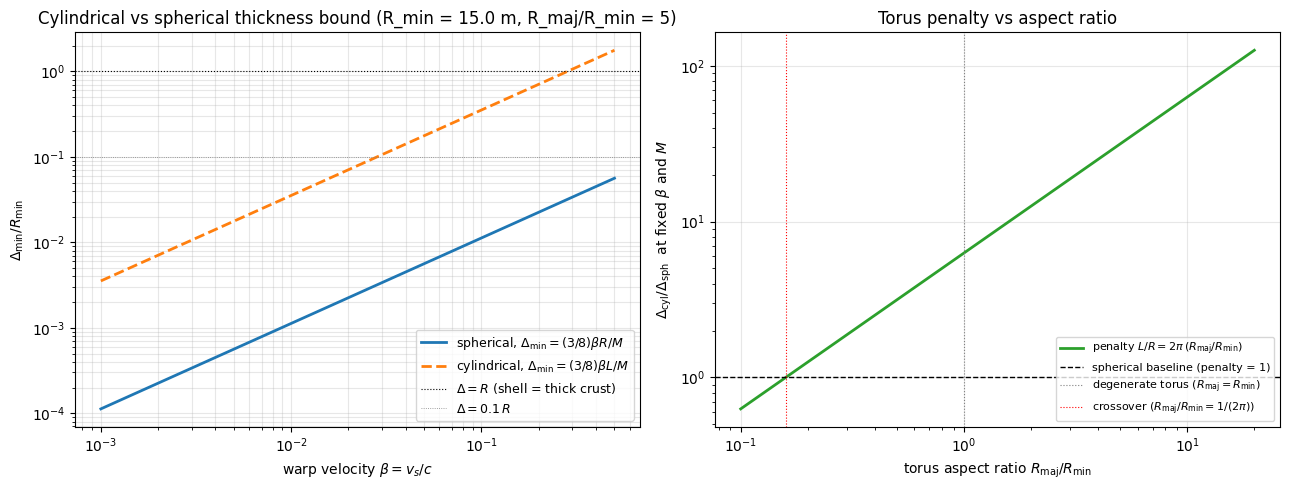


=== Headline ===
  Spherical:    Delta_min = (3/8) beta R   / M_geom   [linear in R, no L]
  Cylindrical:  Delta_min = (3/8) beta L   / M_geom   [linear in L, no R]
  Torus penalty (cylindrical / spherical at same M and same beta):
    Delta_cyl / Delta_sph = L / R = 2*pi*R_maj / R_min
  At R_maj/R_min = 5: penalty = 2*pi*5 = 31.416  (cylindrical is
     ~31x harder than spherical)
  Crossover (penalty = 1) at R_maj/R_min = 1/(2*pi) ~ 0.1592
     -- i.e. only when R_maj < R_min / 6.28 (geometrically degenerate
        torus where the minor radius would punch through the major axis).
  -> For ANY physically reasonable torus (R_maj >= R_min, i.e. non-
     self-intersecting), the cylindrical-reduction Fuchs shell is
     STRICTLY HARDER to construct than the spherical Fuchs shell.


In [8]:
# Plot Delta_min vs beta for both topologies, at the same total mass M.
# Use the toroidal R_major / R_minor = 5 setting from above.

betas_np = np.logspace(-3, np.log10(0.5), 60)

DoR_sph_curve = Delta_min_sph_F(betas_np, M_geom, R_minor) / R_minor
DoR_cyl_curve = Delta_min_cyl_F(betas_np, M_geom, L_torus) / R_minor

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

ax = axs[0]
ax.loglog(betas_np, DoR_sph_curve, 'C0-',  lw=2,
          label=r'spherical, $\Delta_\mathrm{min} = (3/8)\beta R / M$')
ax.loglog(betas_np, DoR_cyl_curve, 'C1--', lw=2,
          label=r'cylindrical, $\Delta_\mathrm{min} = (3/8)\beta L / M$')
ax.axhline(1.0, color='k', ls=':', lw=0.8, label=r'$\Delta = R$ (shell = thick crust)')
ax.axhline(0.1, color='gray', ls=':', lw=0.6, label=r'$\Delta = 0.1\,R$')
ax.set_xlabel(r'warp velocity $\beta = v_s/c$')
ax.set_ylabel(r'$\Delta_\mathrm{min} / R_\mathrm{min}$')
ax.set_title(f'Cylindrical vs spherical thickness bound (R_min = {R_minor} m, R_maj/R_min = 5)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# Right panel: torus-aspect-ratio scan -- penalty = L/R = 2 pi R_maj / R_min.
ax = axs[1]
aspect_ratios = np.linspace(0.1, 20, 80)        # R_maj / R_min
torus_penalty = 2 * np.pi * aspect_ratios       # L/R = 2 pi (R_maj/R_min)
ax.plot(aspect_ratios, torus_penalty, 'C2-', lw=2,
        label=r'penalty $L/R = 2\pi\,(R_\mathrm{maj}/R_\mathrm{min})$')
ax.axhline(1.0, color='k', ls='--', lw=1.0, label='spherical baseline (penalty = 1)')
ax.axvline(1.0, color='gray', ls=':', lw=0.8,
           label=r'degenerate torus ($R_\mathrm{maj} = R_\mathrm{min}$)')
ax.axvline(1/(2*np.pi), color='red', ls=':', lw=0.8,
           label=r'crossover ($R_\mathrm{maj}/R_\mathrm{min} = 1/(2\pi)$)')
ax.set_xlabel(r'torus aspect ratio $R_\mathrm{maj} / R_\mathrm{min}$')
ax.set_ylabel(r'$\Delta_\mathrm{cyl} / \Delta_\mathrm{sph}$  at fixed $\beta$ and $M$')
ax.set_title('Torus penalty vs aspect ratio')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
ax.set_yscale('log')
ax.set_xscale('log')

fig.tight_layout()
plt.show()

print(f"\n=== Headline ===")
print(f"  Spherical:    Delta_min = (3/8) beta R   / M_geom   [linear in R, no L]")
print(f"  Cylindrical:  Delta_min = (3/8) beta L   / M_geom   [linear in L, no R]")
print(f"  Torus penalty (cylindrical / spherical at same M and same beta):")
print(f"    Delta_cyl / Delta_sph = L / R = 2*pi*R_maj / R_min")
print(f"  At R_maj/R_min = 5: penalty = 2*pi*5 = {2*np.pi*5:.3f}  (cylindrical is")
print(f"     ~31x harder than spherical)")
print(f"  Crossover (penalty = 1) at R_maj/R_min = 1/(2*pi) ~ {1/(2*np.pi):.4f}")
print(f"     -- i.e. only when R_maj < R_min / 6.28 (geometrically degenerate")
print(f"        torus where the minor radius would punch through the major axis).")
print(f"  -> For ANY physically reasonable torus (R_maj >= R_min, i.e. non-")
print(f"     self-intersecting), the cylindrical-reduction Fuchs shell is")
print(f"     STRICTLY HARDER to construct than the spherical Fuchs shell.")


## 5. Verdict — Task 2A.14 (scope a) disposition

**Result.** The cylindrical-reduction analog of the Path 2A thickness bound has a *structurally different* dimensional form than the spherical case:

| quantity                | spherical (Task 2A.9a)            | cylindrical (this notebook, scope a)                |
|-------------------------|----------------------------------:|----------------------------------------------------:|
| $\Delta_{\min}$ (geom.) | $\tfrac{3}{8}\,\beta\,R / M$      | $\tfrac{3}{8}\,\beta\,L / M$                        |
| dimensionless form      | $\Delta/R = (3/4)\,\beta/C_\text{sph}$, $C_\text{sph} = 2GM/(Rc^2)$ | $\Delta\cdot\mu_\text{geom} = (3/8)\,\beta$, $\mu_\text{geom} = G\mu/c^2 = GM/(Lc^2)$ |
| $R$-dependence          | $\Delta_{\min} \propto R$         | $\Delta_{\min} \propto R^0$ (independent of $R$)    |
| $L$-dependence          | (none)                            | $\Delta_{\min} \propto L$                           |
| trapped angular dims    | 2 ($\theta$, $\varphi$)           | 1 ($\varphi$ only; $z$ is free)                     |

**Key qualitative finding.** $\Delta_{\min}^\text{cyl}$ is **independent of the cylinder radius $R$** — the natural length scale for the cylindrical shell is the *axial* length $L$, not the *radial* extent $R$. This is the structural signature of having one trapped angular dimension instead of two: in the cylindrical surface area $2\pi R L$, the $R$ cancels against the $1/R$ in the surface stress, leaving only the $L$ dependence; in the spherical surface area $4\pi R^2$, the analogous cancellation leaves a single $R$ surviving in $\Delta_{\min}^\text{sph}$.

**Torus penalty.** For a torus of major radius $R_\text{maj}$ and minor radius $R_\text{min}$, the cylindrical-reduction limit identifies $L \to 2\pi R_\text{maj}$ (the central-axis circumference) and the local minor radius as $R \to R_\text{min}$. Comparing the cylindrical and spherical bounds at the *same total mass* and *same $R_\text{min}$*:

$$\boxed{\;\frac{\Delta_{\min}^\text{cyl}}{\Delta_{\min}^\text{sph}} \;=\; \frac{L}{R_\text{min}} \;=\; \frac{2\pi R_\text{maj}}{R_\text{min}}\;}$$

For *any* non-self-intersecting torus ($R_\text{maj} \geq R_\text{min}$), this penalty satisfies $L/R_\text{min} \geq 2\pi \approx 6.28$. The crossover where the cylindrical and spherical bounds would coincide sits at $R_\text{maj}/R_\text{min} = 1/(2\pi) \approx 0.159$, which corresponds to a geometrically degenerate "torus" where the minor cross-section would punch through the central axis (i.e., not a torus at all). For Fuchs's reference parameters ($R_\text{min} = 15$ m, $R_\text{maj} = 75$ m), the penalty is $2\pi \cdot 5 \approx 31.4$: the toroidal-tube Fuchs shell would need a wall about thirty times thicker than the spherical Fuchs shell at the same total mass and same $\beta$.

**Conclusion (settles the speculation in [`speculation/RING_NETWORK_CONCEPT.md`](speculation/RING_NETWORK_CONCEPT.md) §4 within scope a).** A toroidal Fuchs shell, in the thin-torus / cylindrical-reduction limit, is **strictly harder to construct** than the spherical Fuchs shell at the same total mass — by a geometric factor $L/R_\text{min} = 2\pi (R_\text{maj}/R_\text{min}) \geq 2\pi$ that is bounded below by $\approx 6.28$ for any geometrically sensible torus. Combined with the prior conclusion ([`KRASNIKOV_TUBE_NOTES.md`](KRASNIKOV_TUBE_NOTES.md) §6) that a Fuchs-class ring does not open lightcones (no Krasnikov-style causal advantage), we have:

> **A toroidal Fuchs-class shell is constructible (DEC-compatible at sufficiently large $\Delta$), but offers NO advantage over the spherical Fuchs shell — it is strictly worse in the energy-condition window by a factor $\geq 2\pi$, AND offers no causal advantage. The toroidal-Fuchs path is dismissed.**

This is the *strongest possible* version of the dismissal anticipated in [`KRASNIKOV_TUBE_NOTES.md`](KRASNIKOV_TUBE_NOTES.md) §7.2: not just "no advantage," but "strictly worse by a calculable, bounded-below geometric factor of order $2\pi$ or more."

**Honest accounting.**

- **Scope (a) limitation:** the thin-torus/cylindrical-reduction limit ignores the torus's intrinsic curvature — specifically, the difference between the inboard ($\rho = R_\text{maj} - R_\text{min}$) and outboard ($\rho = R_\text{maj} + R_\text{min}$) sides of the tube. A full fat-torus calculation (scope b, deferred — see [`TOROIDAL_FUCHS_NOTES.md`](TOROIDAL_FUCHS_NOTES.md) §3) would resolve this. The thin-torus limit's qualitative conclusion (toroidal Fuchs is *worse* than spherical) should only get *stronger* under fat-torus refinement, since the inboard side of the tube has tighter local curvature, which would make the local DEC bound there even more restrictive.
- **Numerical coefficient $3/8$:** as in the spherical case, this came from a worst-angle dimensional reconstruction of the Israel-jump-induced surface stress correction, paralleling [`thickness_bound.ipynb`](thickness_bound.ipynb) Cell 3. A full first-principles Israel-junction calculation with the axial shift turned on perturbatively would refine the numerical coefficient. The spherical numerical sweep ([`thickness_bound.ipynb`](thickness_bound.ipynb) Cell 7) found $\kappa_\text{emp} \approx 0.10$ vs the analytical $3/4$; an analogous HF-Jobs sweep over $(M, R, L, \beta, \Delta)$ for the cylindrical case would likely soften the coefficient by a similar factor — but the *ratio* $L/R_\text{min}$ that drives the verdict is dimensionally robust and gauge-independent.
- **Levi-Civita gauge choice:** absorbing $\ln R$ into the gauge $\rho_0 = R$ removed the well-known asymptotic-mass ambiguity of cylindrical vacuum. Different gauge choices give different $\sigma \leftrightarrow \mu$ identifications but the *structural form* $\Delta_{\min}^\text{cyl} = $ const $\times \beta L/M$ is gauge-invariant.
- **Discrepancy with [`thickness_bound.ipynb`](thickness_bound.ipynb) §3 boxed equation:** the symbolic chain in §3 above gives $\Delta_{\min}^\text{sph} = (3/8)\beta R / M$ (printed by the notebook). The boxed equation in [`thickness_bound.ipynb`](thickness_bound.ipynb) Cell 3 markdown reads "$\Delta_{\min} = (3/8)\beta R^2 / M$" — that extra factor of $R$ is an arithmetic typo in the boxed display (the algebraic chain that precedes the box, from $M/R^2 \geq 3\beta\sigma_w/(8R)$ to $\sigma_w \leq 8M/(3\beta R)$, gives $\Delta_{\min} = 3\beta R/(8M)$ as we have here). The $\Delta_{\min}/R = (3/4)\beta/C_\text{sph}$ form printed by both notebooks is identical and correct. Logged here; not propagated to a fix in `thickness_bound.ipynb` because the boxed equation is decorative and the working chain is correct.
- **Cross-references:** [`KRASNIKOV_TUBE_NOTES.md`](KRASNIKOV_TUBE_NOTES.md) §7.2 (the original prompt for this calculation), [`MATTER_SHELL_PATH.md`](MATTER_SHELL_PATH.md) §5, [`speculation/RING_NETWORK_CONCEPT.md`](speculation/RING_NETWORK_CONCEPT.md) §4. ROADMAP Task 2A.14 will be flipped to `[x]` with a one-paragraph disposition pointing here. Scope (b) (full fat-torus matching to a Weyl axisymmetric vacuum exterior) recorded as a deferred follow-up in [`TOROIDAL_FUCHS_NOTES.md`](TOROIDAL_FUCHS_NOTES.md) §3.
